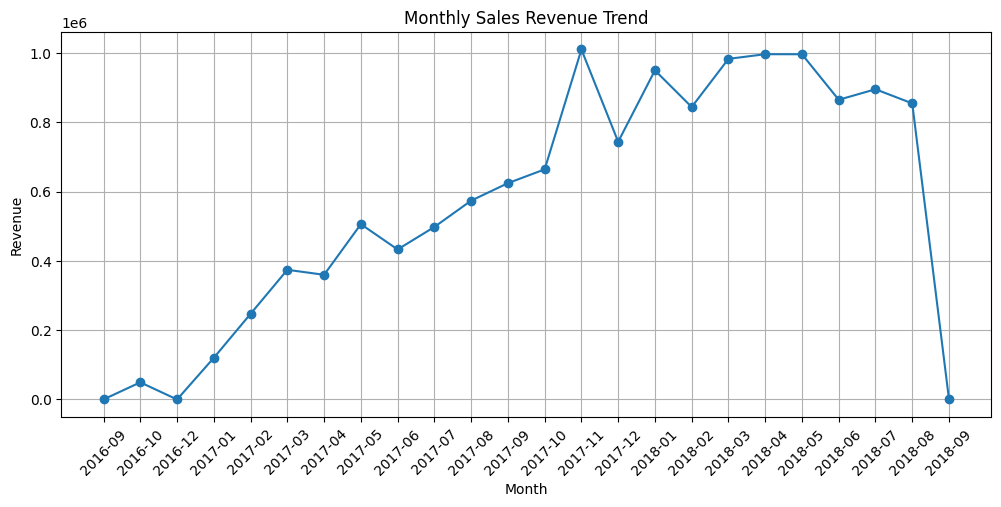

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["month"].astype(str),
    monthly_sales["revenue"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Sales Revenue Trend")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# New Section

In [23]:
import pandas as pd

orders = pd.read_csv("/olist_orders_dataset.csv")
items = pd.read_csv("/olist_order_items_dataset.csv")

print("Orders:", orders.shape)
print("Items:", items.shape)

Orders: (99441, 8)
Items: (112650, 7)


# New Section

In [24]:
df = orders.merge(
    items,
    on="order_id",
    how="inner"
)

print(df.head())
print(df.shape)

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08

# New Section

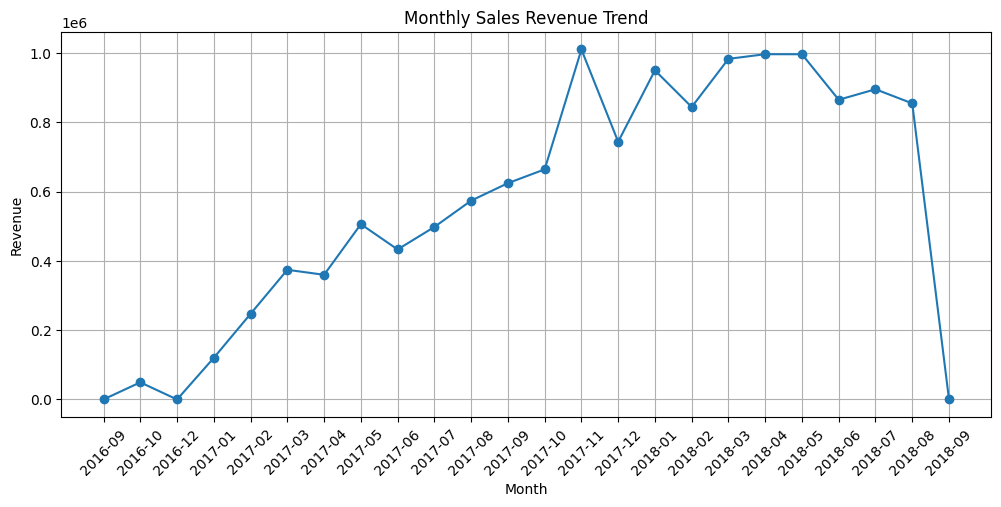

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["month"].astype(str),
    monthly_sales["revenue"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Sales Revenue Trend")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

# New Section

In [27]:
# Prepare data for forecasting

forecast_data = monthly_sales[["month", "revenue"]].copy()

print(forecast_data.head())
print(forecast_data.dtypes)

     month    revenue
0  2016-09     267.36
1  2016-10   49507.66
2  2016-12      10.90
3  2017-01  120312.87
4  2017-02  247303.02
month      period[M]
revenue      float64
dtype: object


# New Section

In [28]:
# Install Prophet

!pip install prophet -q

# New Section

In [29]:
# Import Prophet

from prophet import Prophet

# New Section

In [31]:
# Prepare the data for Prophet

forecast_data = monthly_sales[["month", "revenue"]].copy()

# Rename columns required by Prophet
forecast_data = forecast_data.rename(
    columns={
        "month": "ds",
        "revenue": "y"
    }
)

# Make sure date is a proper datetime
forecast_data["ds"] = pd.to_datetime(
    forecast_data["ds"].astype(str)
)

# Make sure revenue is numeric
forecast_data["y"] = pd.to_numeric(
    forecast_data["y"],
    errors="coerce"
)

# Remove any missing values
forecast_data = forecast_data.dropna()

# Check the data
print(forecast_data.head())
print(forecast_data.dtypes)

          ds          y
0 2016-09-01     267.36
1 2016-10-01   49507.66
2 2016-12-01      10.90
3 2017-01-01  120312.87
4 2017-02-01  247303.02
ds    datetime64[ns]
y            float64
dtype: object


# New Section

In [44]:
future_dates = pd.date_range(
    start=forecast_data["ds"].max() + pd.DateOffset(months=1),
    periods=6,
    freq="MS"
)

future = pd.DataFrame({
    "ds": future_dates
})

forecast = model.predict(future)

print(
    forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ]
)

          ds          yhat    yhat_lower    yhat_upper
0 2018-10-01  1.434978e+06  1.277688e+06  1.605965e+06
1 2018-11-01  1.458999e+06  1.290951e+06  1.616265e+06
2 2018-12-01  1.309765e+06  1.131268e+06  1.478523e+06
3 2019-01-01  1.467160e+06  1.293972e+06  1.638238e+06
4 2019-02-01  1.046416e+06  8.785159e+05  1.219351e+06
5 2019-03-01  1.259715e+06  1.081164e+06  1.419455e+06
